Cell 1: Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell 2: Paths

In [2]:
from pathlib import Path

REPO_NAME = "isro-exoplanet-hackathon-2026"
REPO_PATH = Path(f"/content/{REPO_NAME}")

DRIVE_ROOT = Path("/content/drive/MyDrive/exoplanet_hackathon")
RAW_DIR = DRIVE_ROOT / "data" / "raw_lightcurves"
PROC_DIR = DRIVE_ROOT / "data" / "processed_lightcurves"
FIG_DIR = DRIVE_ROOT / "outputs" / "figures"
TLS_DIR = DRIVE_ROOT / "outputs" / "tls_results"

for d in [RAW_DIR, PROC_DIR, FIG_DIR, TLS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Paths ready.")

Paths ready.


Cell 3: Install packages

In [3]:
!pip -q install lightkurve transitleastsquares wotan astropy pandas numpy matplotlib scipy

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 95.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is 

Cell 4: Imports

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightkurve as lk
from astropy.stats import sigma_clip
from transitleastsquares import transitleastsquares

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

print("Imports successful.")

Imports successful.


## Download one fixed sector explicitly

Cell 5: Search target

In [5]:
TARGET = "TIC 261136679"

search_result = lk.search_lightcurve(
    TARGET,
    mission="TESS",
    author="SPOC"
)

print(search_result)

SearchResult containing 42 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 01 2018   SPOC     120   261136679      0.0
  1 TESS Sector 04 2018   SPOC     120   261136679      0.0
  2 TESS Sector 08 2019   SPOC     120   261136679      0.0
  3 TESS Sector 11 2019   SPOC     120   261136679      0.0
  4 TESS Sector 12 2019   SPOC     120   261136679      0.0
  5 TESS Sector 13 2019   SPOC     120   261136679      0.0
  6 TESS Sector 27 2020   SPOC      20   261136679      0.0
  7 TESS Sector 28 2020   SPOC      20   261136679      0.0
  8 TESS Sector 31 2020   SPOC      20   261136679      0.0
  9 TESS Sector 27 2020   SPOC     120   261136679      0.0
 10 TESS Sector 28 2020   SPOC     120   261136679      0.0
 11 TESS Sector 31 2020   SPOC     120   261136679      0.0
 12 TESS Sector 34 2021   SPOC      20   261136679      0

Cell 6: Convert search table to dataframe

In [6]:
search_df = search_result.table.to_pandas()
search_df[["mission", "author", "exptime", "target_name"]].head(15)

,mission,author,exptime,target_name
0,TESS Sector 01,SPOC,120.0,261136679
1,TESS Sector 04,SPOC,120.0,261136679
2,TESS Sector 08,SPOC,120.0,261136679
3,TESS Sector 11,SPOC,120.0,261136679
4,TESS Sector 12,SPOC,120.0,261136679
5,TESS Sector 13,SPOC,120.0,261136679
6,TESS Sector 27,SPOC,20.0,261136679
7,TESS Sector 28,SPOC,20.0,261136679
8,TESS Sector 31,SPOC,20.0,261136679
9,TESS Sector 27,SPOC,120.0,261136679


Cell 7: Select Sector 1, 120 s cadence explicitly

In [7]:
sector_mask = (
    search_df["mission"].astype(str).str.contains("Sector 01", case=False, na=False)
    & (search_df["exptime"] == 120)
)

selected_idx = search_df[sector_mask].index.tolist()
print("Matching indices:", selected_idx)

if len(selected_idx) == 0:
    raise ValueError("Sector 01 120s product not found for this target.")

selected_row = selected_idx[0]
print("Selected row:", selected_row)
search_df.loc[selected_row]

Matching indices: [0]
Selected row: 0


,0
intentType,science
obs_collection,TESS
provenance_name,SPOC
instrument_name,Photometer
project,TESS
...,...
author,SPOC
mission,TESS Sector 01
#,0
year,2018


Cell 8: Download selected sector

In [8]:
lc = search_result[selected_row].download()
print(lc)

       time             flux      ...   pos_corr1      pos_corr2   
                    electron / s  ...      pix            pix      
------------------ -------------- ... -------------- --------------
1325.2969604950604  1.4641956e+06 ...  9.0913408e-02 -7.2966635e-02
1325.2983493645327  1.4643365e+06 ...  6.2022530e-02 -1.0871942e-01
 1325.299738234005  1.4643485e+06 ...  6.1673984e-02 -1.1394957e-01
 1325.301127103477  1.4643674e+06 ...  6.0909923e-02 -1.2573890e-01
1325.3025159730657  1.4642560e+06 ...  5.3837594e-02 -1.2532526e-01
 1325.303904842538  1.4644681e+06 ...  5.2977830e-02 -1.2562653e-01
1325.3052937121265  1.4643586e+06 ...  5.7222184e-02 -1.3051888e-01
1325.3066825815986  1.4643564e+06 ...  5.5443291e-02 -1.2712292e-01
1325.3080714511873  1.4645452e+06 ...  5.1877767e-02 -1.2947108e-01
               ...            ... ...            ...            ...
1353.1645661947705  1.4646795e+06 ...  5.5579260e-02 -1.1038263e-02
1353.1659550506233  1.4649392e+06 ...  6.0031198

## 2) Extract the correct flux and quality columns

This time we do it explicitly from the table columns, not from lc.flux.

Cell 9: Extract raw arrays

In [9]:
time = np.array(lc.time.value, dtype=float)
pdcsap_flux = np.array(lc["pdcsap_flux"].value, dtype=float)
pdcsap_flux_err = np.array(lc["pdcsap_flux_err"].value, dtype=float)
quality = np.array(lc["quality"], dtype=int)

print("Length:", len(time))
print("Unique quality flags (first few):", np.unique(quality)[:20])
print("Flux median:", np.nanmedian(pdcsap_flux))

Length: 18264
Unique quality flags (first few): [0]
Flux median: 1464602.25


## 3) Quality filtering

For the first pass, keep it strict and simple:

require finite time/flux
require quality == 0
Cell 10: Quality mask

In [10]:
mask = (
    np.isfinite(time)
    & np.isfinite(pdcsap_flux)
    & np.isfinite(pdcsap_flux_err)
    & (quality == 0)
)

time_q = time[mask]
flux_q = pdcsap_flux[mask]
fluxerr_q = pdcsap_flux_err[mask]

print("Original points:", len(time))
print("After quality filtering:", len(time_q))

Original points: 18264
After quality filtering: 18264


Cell 11: Plot quality-filtered flux

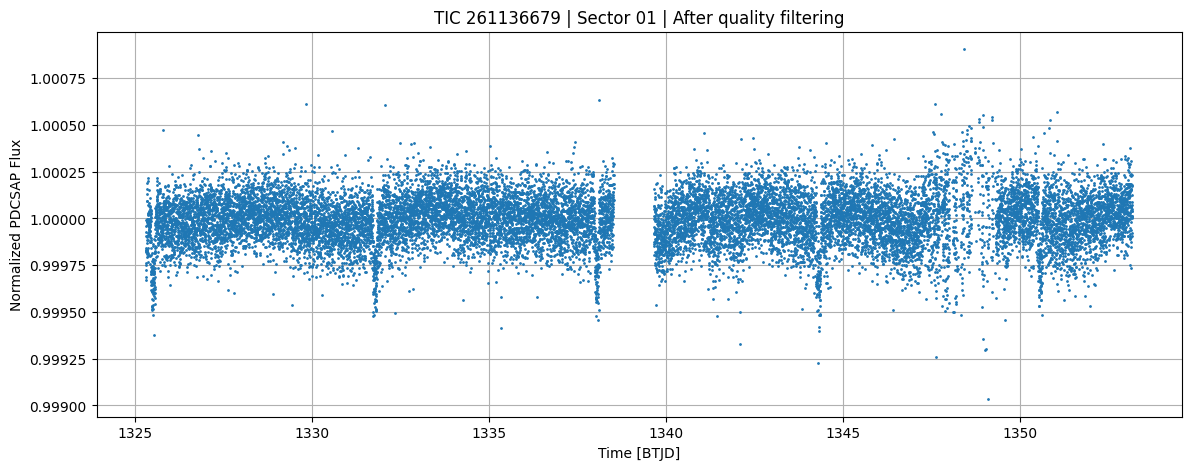

In [11]:
flux_q_norm = flux_q / np.nanmedian(flux_q)

plt.figure(figsize=(14,5))
plt.plot(time_q, flux_q_norm, ".", ms=2)
plt.xlabel("Time [BTJD]")
plt.ylabel("Normalized PDCSAP Flux")
plt.title(f"{TARGET} | Sector 01 | After quality filtering")
plt.show()

## 4) Sigma clipping

We want to remove obvious outliers before TLS.

Cell 12: Sigma clip

In [12]:
clipped = sigma_clip(flux_q, sigma=5, maxiters=3, masked=True)
good = ~clipped.mask

time_sc = time_q[good]
flux_sc = flux_q[good]
fluxerr_sc = fluxerr_q[good]

print("After sigma clipping:", len(time_sc))

After sigma clipping: 18257


Cell 13: Plot after sigma clipping

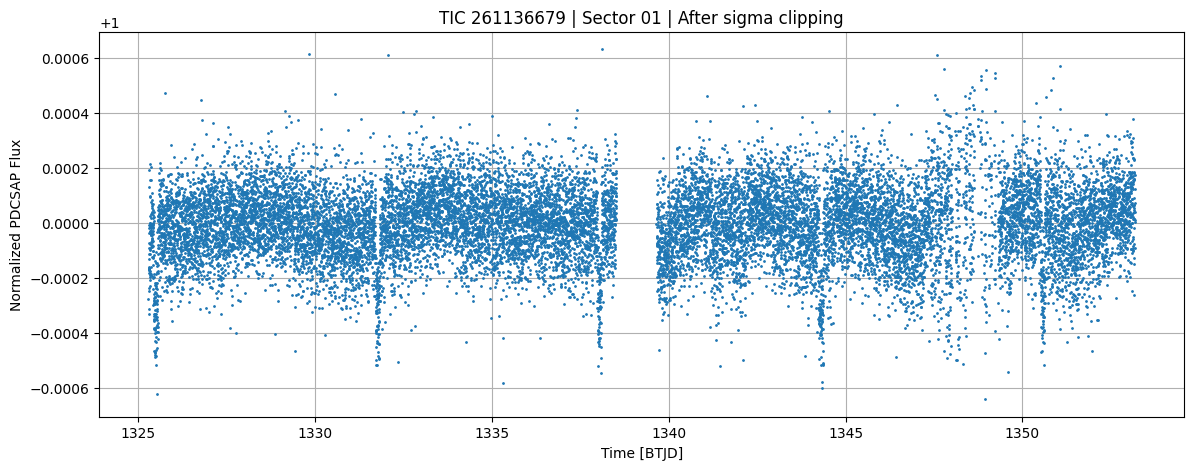

In [13]:
flux_sc_norm = flux_sc / np.nanmedian(flux_sc)

plt.figure(figsize=(14,5))
plt.plot(time_sc, flux_sc_norm, ".", ms=2)
plt.xlabel("Time [BTJD]")
plt.ylabel("Normalized PDCSAP Flux")
plt.title(f"{TARGET} | Sector 01 | After sigma clipping")
plt.show()

## 5) Flatten / detrend for TLS

For the first run, use Lightkurve’s built-in flatten() rather than Wotan.
Reason: fewer moving parts for the first debug run. We can switch to Wotan after we confirm TLS works.

Cell 14: Rebuild a LightCurve object from cleaned arrays

In [14]:
lc_clean = lk.LightCurve(
    time=time_sc,
    flux=flux_sc,
    flux_err=fluxerr_sc
)

print(lc_clean)

       time            flux         flux_err     
                                                 
------------------ ----------- ------------------
1325.2969604950604 1464195.625        130.3671875
1325.2983493645327   1464336.5 130.35809326171875
 1325.299738234005   1464348.5 130.35931396484375
 1325.301127103477 1464367.375 130.35008239746094
1325.3025159730657   1464256.0 130.34835815429688
 1325.303904842538 1464468.125 130.35623168945312
1325.3052937121265 1464358.625  130.3538055419922
1325.3066825815986 1464356.375  130.3552703857422
1325.3080714511873  1464545.25 130.35765075683594
               ...         ...                ...
1353.1645661947705   1464679.5 130.39950561523438
1353.1659550506233  1464939.25 130.41253662109375
 1353.167343906477 1464621.375 130.39376831054688
1353.1687327622717 1464783.375 130.40989685058594
 1353.170121618124 1464465.625  130.3860321044922
1353.1715104739196 1464708.125 130.39996337890625
1353.1728993297734 1464660.625 130.40235900878906


Cell 15: Flatten

Use a moderate window length first.

In [15]:
lc_flat = lc_clean.flatten(window_length=401)

print(lc_flat)

       time               flux               flux_err      
                                                           
------------------ ------------------ ---------------------
1325.2969604950604  0.999818491164347 8.902056697757822e-05
1325.2983493645327 0.9999149865166154 8.901438369263021e-05
 1325.299738234005 0.9999234771739925 8.901524364025555e-05
 1325.301127103477 0.9999366593335268 8.900896602969391e-05
1325.3025159730657 0.9998608977840678 8.900781448656143e-05
 1325.303904842538 1.0000060337694199 8.901321647331696e-05
1325.3052937121265 0.9999315464014814 8.901158509236236e-05
1325.3066825815986 0.9999302911884347  8.90126103864316e-05
1325.3080714511873 1.0000595419390461 8.901426057278291e-05
               ...                ...                   ...
1353.1645661947705 0.9999666239517758 8.902640707065714e-05
1353.1659550506233 1.0001435414111555 8.903526628877799e-05
 1353.167343906477 0.9999261009241055 8.902241531984082e-05
1353.1687327622717  1.000036278937108 8.

Cell 16: Plot flattened light curve

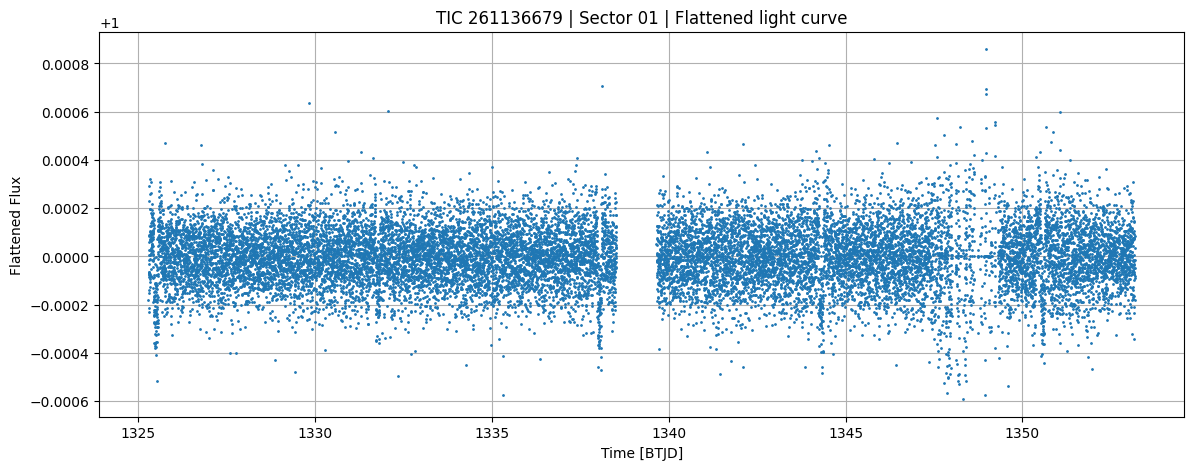

In [16]:
time_flat = np.array(lc_flat.time.value, dtype=float)
flux_flat = np.array(lc_flat.flux.value, dtype=float)

plt.figure(figsize=(14,5))
plt.plot(time_flat, flux_flat, ".", ms=2)
plt.xlabel("Time [BTJD]")
plt.ylabel("Flattened Flux")
plt.title(f"{TARGET} | Sector 01 | Flattened light curve")
plt.show()

## 6) Run Transit Least Squares

Now the actual first transit search.

Cell 17: TLS search

Use a restricted period range first to keep it fast and stable

In [17]:
model = transitleastsquares(time_flat, flux_flat)

results = model.power(
    period_min=0.5,
    period_max=15.0,
    oversampling_factor=5,
    show_progress_bar=True
)

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 18257 data points, 4255 periods from 0.601 to 13.94 days
Using all 2 CPU threads


100%|██████████| 4255/4255 periods | 01:21<00:00


Searching for best T0 for period 6.26546 days


## 7) Inspect TLS results
Cell 18: Print key outputs

In [18]:
print("Best period:", results.period)
print("Transit duration:", results.duration)
print("Transit depth:", results.depth)
print("Epoch t0:", results.T0)
print("SDE:", results.SDE)
print("SNR:", getattr(results, "snr", "not available"))
print("FAP:", getattr(results, "FAP", "not available"))

Best period: 6.2654594827068175
Transit duration: 0.12473677727019772
Transit depth: 0.9998092010149855
Epoch t0: 1325.5107304675926
SDE: 19.333579520306465
SNR: 27.916766975121877
FAP: 8.0032e-05


## 8) Plot the TLS periodogram
Cell 19: TLS power plot

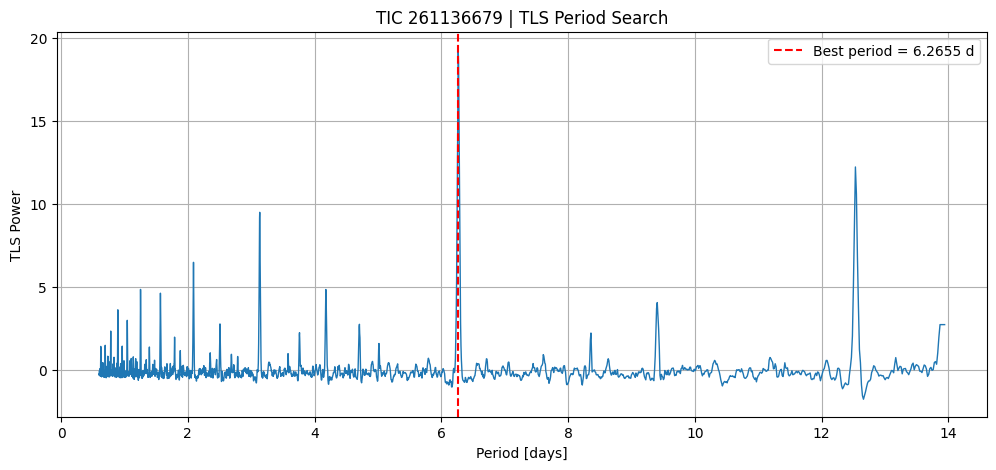

In [19]:
plt.figure(figsize=(12,5))
plt.plot(results.periods, results.power, lw=1)
plt.axvline(results.period, color="red", ls="--", label=f"Best period = {results.period:.4f} d")
plt.xlabel("Period [days]")
plt.ylabel("TLS Power")
plt.title(f"{TARGET} | TLS Period Search")
plt.legend()
plt.show()

## 9) Phase-fold at the detected period
Cell 20: Build folded phase

In [20]:
period = results.period
t0 = results.T0

phase = ((time_flat - t0 + 0.5 * period) % period) / period - 0.5
sort_idx = np.argsort(phase)

phase_sorted = phase[sort_idx]
flux_sorted = flux_flat[sort_idx]

Cell 21: Plot folded light curve

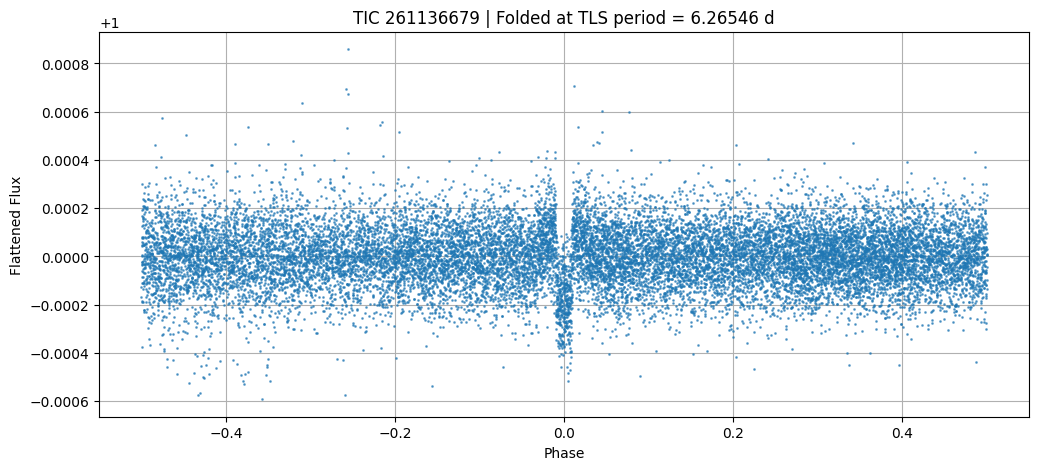

In [21]:
plt.figure(figsize=(12,5))
plt.plot(phase_sorted, flux_sorted, ".", ms=2, alpha=0.6)
plt.xlabel("Phase")
plt.ylabel("Flattened Flux")
plt.title(f"{TARGET} | Folded at TLS period = {period:.5f} d")
plt.show()

## 10) Save processed arrays and TLS summary

We want to persist the first result.

Cell 22: Save processed light curve CSV

In [22]:
processed_df = pd.DataFrame({
    "time": time_flat,
    "flux_flat": flux_flat
})

proc_csv = PROC_DIR / "tic_261136679_sector01_flattened.csv"
processed_df.to_csv(proc_csv, index=False)

print("Saved processed CSV:", proc_csv)

Saved processed CSV: /content/drive/MyDrive/exoplanet_hackathon/data/processed_lightcurves/tic_261136679_sector01_flattened.csv


Cell 23: Save TLS summary CSV

In [23]:
tls_summary = pd.DataFrame([{
    "target": TARGET,
    "sector": 1,
    "cadence_sec": 120,
    "best_period": results.period,
    "duration": results.duration,
    "depth": results.depth,
    "t0": results.T0,
    "sde": results.SDE
}])

tls_csv = TLS_DIR / "tic_261136679_sector01_tls_summary.csv"
tls_summary.to_csv(tls_csv, index=False)

print("Saved TLS summary:", tls_csv)
tls_summary

Saved TLS summary: /content/drive/MyDrive/exoplanet_hackathon/outputs/tls_results/tic_261136679_sector01_tls_summary.csv


,target,sector,cadence_sec,best_period,duration,depth,t0,sde
0,TIC 261136679,1,120,6.265459,0.124737,0.999809,1325.51073,19.33358


Cell 24: Save folded plot

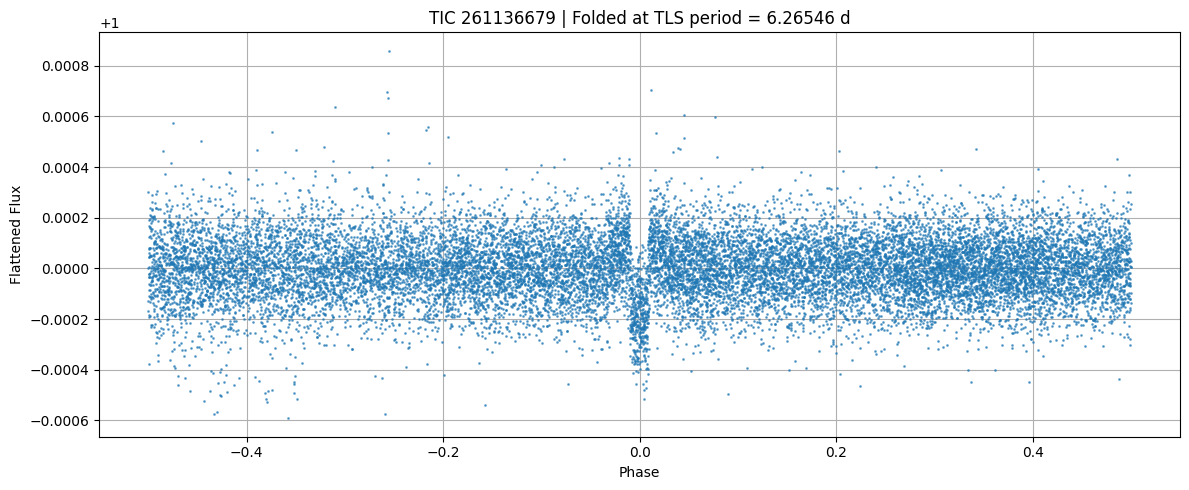

Saved folded plot: /content/drive/MyDrive/exoplanet_hackathon/outputs/figures/tic_261136679_sector01_folded_tls.png


In [25]:
fig_path = FIG_DIR / "tic_261136679_sector01_folded_tls.png"

plt.figure(figsize=(12,5))
plt.plot(phase_sorted, flux_sorted, ".", ms=2, alpha=0.6)
plt.xlabel("Phase")
plt.ylabel("Flattened Flux")
plt.title(f"{TARGET} | Folded at TLS period = {period:.5f} d")
plt.tight_layout()
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved folded plot:", fig_path)

# Step 3.5

In [26]:
print(results)

{'SDE': np.float64(19.333579520306465), 'SDE_raw': np.float64(16.625444075866735), 'chi2_min': np.float64(17438.574018413423), 'chi2red_min': np.float64(0.9553812534056552), 'period': np.float64(6.2654594827068175), 'period_uncertainty': np.float64(0.02194371183206112), 'T0': np.float64(1325.5107304675926), 'duration': np.float64(0.12473677727019772), 'depth': np.float64(0.9998092010149855), 'depth_mean': (np.float64(0.99983460363877), np.float64(6.0346415141792595e-06)), 'depth_mean_even': (np.float64(0.9998247560373374), np.float64(7.894790520226139e-06)), 'depth_mean_odd': (np.float64(0.9998499158051594), np.float64(9.208378413667565e-06)), 'transit_depths': array([0.9998155 , 0.99989136, 0.99982034, 0.999806  , 0.99983833]), 'transit_depths_uncertainties': array([1.37498775e-05, 1.17868978e-05, 1.36323627e-05, 1.26127436e-05,
       1.35231240e-05]), 'rp_rs': np.float64(0.012422104456591969), 'snr': np.float64(27.916766975121877), 'snr_per_transit': array([13.97390803,  8.22824655,

In [27]:
print(results.__dict__.keys())

dict_keys([])


In [28]:
for key, value in results.__dict__.items():
    if "depth" in key.lower():
        print(key, value)

In [29]:
print("Depth:", results.depth)

print("1 - depth:", 1 - results.depth)

Depth: 0.9998092010149855
1 - depth: 0.00019079898501450643
